# Diafiltration Flowsheet Setup

In [1]:
# imports
import sys

from pyomo.environ import (
    SolverFactory,
    TransformationFactory,
    assert_optimal_termination,
    value,
)

from idaes.core.util import to_json, from_json
from idaes.core.util.model_diagnostics import DiagnosticsToolbox
from idaes.core.util.model_statistics import report_statistics

from prommis.nanofiltration.membrane_cascade_flowsheet import utils
from prommis.nanofiltration.membrane_cascade_flowsheet.diafiltration_flowsheet_model import (
    DiafiltrationModel,
)
from multistart_solve import MultistartSolve

## Methods

In [2]:
mix_style = "stage"

def solve_scaled_model(m, L, C):
    m.recovery_li = L
    m.recovery_co = C

    scaling = TransformationFactory("core.scale_model")
    solver = SolverFactory("ipopt")
    solver = SolverFactory('multistart_solve')
    solver.mix = mix_style
    solver.dsolver = 'ipopt'

    scaled_model = scaling.create_using(m, rename=False)
    result = solver.solve(scaled_model, tee=False)
    assert_optimal_termination(result)
    # Propagate results back to unscaled model
    scaling.propagate_solution(scaled_model, m)

    return result

## Flowsheet Setup

In [3]:
# Setting up flowsheet with following settings:
num_s = 3    # number of stages
num_t = 10   # number of tubes per stage

# set relevant parameter values
solutes = ["Li", "Co"]
flux = 0.1  # m3 / m2 / h
sieving_coefficient = {"Li": 1.3, "Co": 0.5}
feed = {
    "solvent": 100,  # m^3/hr of water
    "Li": 1.7 * 100,  # kg/hr
    "Co": 17 * 100,  # kg/hr
}
diaf = {
    "solvent": 30,  # m^3/hr of water
    "Li": 0.1 * 30,  # kg/hr
    "Co": 0.2 * 30,  # kg/hr
}

# toggle for precipitator use
precipitate = True

# setup for diafiltration model
df = DiafiltrationModel(
    NS=num_s,
    NT=num_t,
    solutes=solutes,
    flux=flux,
    sieving_coefficient=sieving_coefficient,
    feed=feed,
    diafiltrate=diaf,
    precipitate=precipitate,
    precipitate_yield={
        "permeate": {"Li": 0.81, "Co": 0.01},
        "retentate": {"Li": 0.20, "Co": 0.89},
    },
)

# Build model flowsheet
m = df.build_flowsheet(mixing=mix_style)

# initialize (from saved initialization or from scratch)
saved_initialization = False
if saved_initialization:
    from_json(m, fname="initialized_model_stage_3_10")
else:
    df.initialize(m, mixing=mix_style, precipitate=precipitate)
    to_json(m, fname="initialized_model_stage_3_10")

# unfix degrees of freedom
df.unfix_dof(m, mixing=mix_style, precipitate=precipitate)

# set diafiltrate flow rate upper bound
m.fs.split_diafiltrate.inlet.flow_vol.setub(2000)

# print model statistics
report_statistics(m)

**************************************************
* Diafiltration Flowsheet Initialization
**************************************************
  Membranes Iteration: 0
  =>Recycle Error: 43.33333333333333
  Membranes Iteration: 1
  =>Recycle Error: 19.166666666666664
  Membranes Iteration: 2
  =>Recycle Error: 9.583333335833338
  Membranes Iteration: 3
  =>Recycle Error: 0.0
Precipitator Iteration 0
=>Recycle Error: -2.99999920153998

  Membranes Iteration: 0
  =>Recycle Error: 38.33333338410256
  Membranes Iteration: 1
  =>Recycle Error: 16.66666669205128
  Membranes Iteration: 2
  =>Recycle Error: 8.333333348525642
  Membranes Iteration: 3
  =>Recycle Error: 0.0
Precipitator Iteration 1
=>Recycle Error: -1.384667285042667e-08

  Membranes Iteration: 0
  =>Recycle Error: 37.75641030726824
  Membranes Iteration: 1
  =>Recycle Error: 16.378205153634127
  Membranes Iteration: 2
  =>Recycle Error: 8.189102579317066
  Membranes Iteration: 3
  =>Recycle Error: 0.0
Precipitator Iteration 2
=


Model Statistics   

Degrees of Freedom: 43 

Total No. Variables: 1018 
    No. Fixed Variables: 110
    No. Unused Variables: 6 (Fixed):0)
    No. Variables only in Inequalities: 0 (Fixed: 0) 

Total No. Constraints: 903 
    No. Equality Constraints: 879 (Deactivated: 20)
    No. Inequality Constraints: 24 (Deactivated: 5)

No. Objectives: 4 (Deactivated: 3)

No. Blocks: 277 (Deactivated: 0) 
No. Expressions: 12 



In [4]:
# Setting up flowsheet costing with following settings:
costing = True

# pressure for pump costing
atmospheric_pressure = 101.325  # ambient pressure, kPa
operating_pressure = 145  # nanofiltration operating pressure, psi

# costing model settings
simple_costing = True
npv = False

# build flowsheet costing
if costing:
    df.add_costing(
        m,
        NS=num_s,
        flux=flux,
        feed=feed,
        diaf=diaf,
        precipitate=precipitate,
        atmospheric_pressure=atmospheric_pressure,
        operating_pressure=operating_pressure,
        simple_costing=simple_costing,
        npv=npv,
    )
    df.add_costing_objectives(m, npv=npv)
    # df.add_costing_scaling(m, NS=num_s, simple_costing=simple_costing)

# set recovery lower bounds
lithium_recovery = 0.7
cobalt_recovery = 0.7

# set precipitator reagent prices
# m.fs.lithium_carbonate_price = 30
# m.fs.cobalt_oxalate_price = 30

In [8]:
import pyomo.environ as pyo
for var in m.fs.costing.component_data_objects(pyo.Var):
    if var.value is None:
        print(var)

## Solving and Results

In [5]:
solve_scaled_model(
    m,
    L=lithium_recovery,
    C=cobalt_recovery,
)

# some diagnostics checks
# dt = DiagnosticsToolbox(m)
# some flows are at their bounds of zero
# dt.report_numerical_issues()

if costing:
    if not simple_costing:
        # Verify the feed pump operating pressure workaround is valid
        # assume this additional cost is less than half a cent
        if value(m.fs.feed_pump.costing.variable_operating_cost) >= 0.005:
            raise ValueError(
                "The variable  operating cost of the feed pump as calculated in the feed"
                "pump costing block is not negligible. This operating cost is already"
                "accounted for via the membrane's pressure drop specific energy consumption."
            )

Stage: 1
ok
locallyOptimal
ok
locallyOptimal
Stage: 2
ok
locallyOptimal
ok
locallyOptimal
Stage: 3
ok
locallyOptimal
ok
locallyOptimal


prec_perc_co : Size=1
    Key  : Value
    None :   0.7
prec_perc_li : Size=1
    Key  : Value
    None :   0.7
Membrane outlet recoveries
rec_perc_co : Size=1
    Key  : Value
    None : 0.6926513102248782
rec_perc_li : Size=1
    Key  : Value
    None : 0.9186193359350849
Membrane Area
length : Size=1, Index=None, Units=m
    Key  : Lower : Value              : Upper   : Fixed : Stale : Domain
    None :   0.1 : 1176.9913385931586 : 10000.0 : False :  True :  Reals
length : Size=1, Index=None, Units=m
    Key  : Lower : Value              : Upper   : Fixed : Stale : Domain
    None :   0.1 : 1176.9913385931586 : 10000.0 : False :  True :  Reals
length : Size=1, Index=None, Units=m
    Key  : Lower : Value              : Upper   : Fixed : Stale : Domain
    None :   0.1 : 1176.9913385931586 : 10000.0 : False :  True :  Reals
feed flows
Stage 1
0.0
Stage 2
100.0
Stage 3
0.0

diaf flows
Stage 1
0.0
Stage 2
0.0
Stage 3
46.51172315385323

recycle flows
Stage 1
146.5117231638533
Stage 2
46

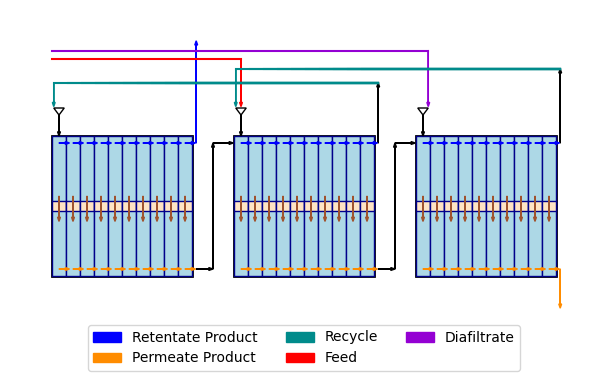

In [6]:
# printing results
# NOTE These percent recoveries are for precipitators
m.prec_perc_co.display()
m.prec_perc_li.display()

# m.fs.costing.total_annualized_cost.display()

# Print all relevant flow information
vals = utils.report_values(m)
utils.visualize_flows(
    num_boxes=num_s, num_sub_boxes=num_t, conf=mix_style, model=vals
)